In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
data = pd.read_csv("Nat_Gas.csv")
data["Date"] = pd.to_datetime(data["Date"])
data.set_index("Date", inplace=True)
data.head()

C:\Users\somya\AppData\Local\Temp\ipykernel_17416\1013084115.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(data["Date"])


,Price
Date,
2020-10-31,10.1
2020-11-30,10.3
2020-12-31,11.0
2021-01-31,10.9
2021-02-28,10.9


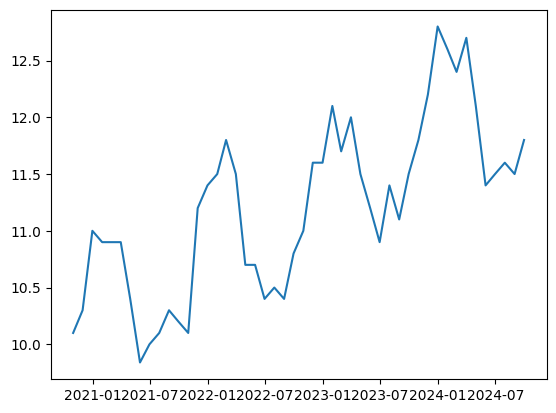

In [14]:
plt.plot(data)
plt.show()

In [ ]:
decomposition = seasonal_decompose(data["Price"], model ='additive', period=12)

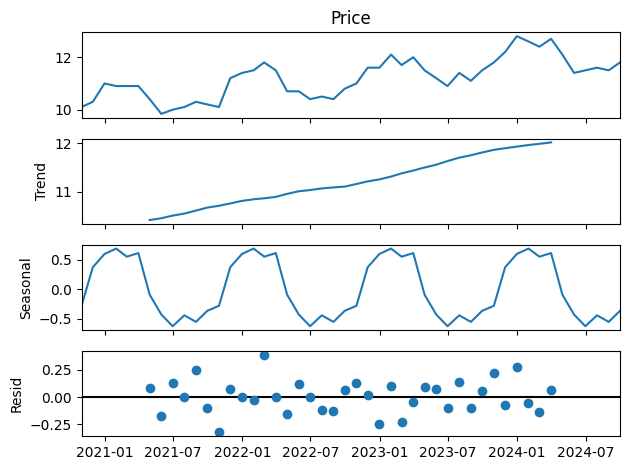

In [4]:
fig = decomposition.plot()
plt.show()

In [ ]:
model = ARIMA(data["Price"], order=(1, 1, 12))
model_fit = model.fit()

c:\Users\somya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\somya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\somya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\somya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\somya\AppData\Local

In [10]:
forecast = model_fit.forecast(steps=12)

C:\Users\somya\AppData\Local\Temp\ipykernel_17416\2800376076.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


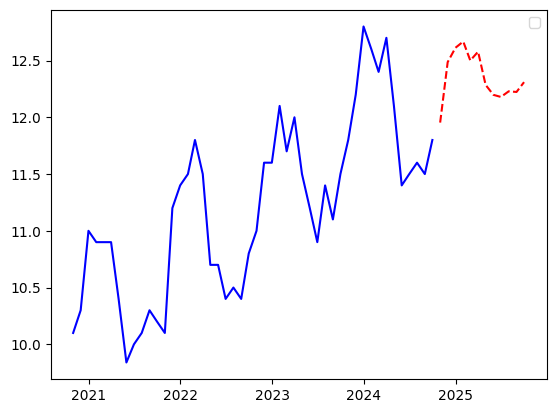

In [20]:
future_dates = pd.date_range(start = data.index[-1], periods = 13, freq = 'ME')[1:]
plt.plot(data.index, data["Price"], color = 'blue')
plt.plot(future_dates, forecast, linestyle = "--", color =  'red')
plt.legend()
plt.show()